# Week 5 — Additional Models: Decision Tree & Random Forest

Reuses the leakage-exclusion logic from `03_baseline_model.ipynb`, adds
Decision Tree and Random Forest, and compares test R2 against baseline.


## 1. Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import glob

path = '/content/drive/MyDrive/idx_dataset/'
files = glob.glob(path + 'cleaned_df.csv')

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df.shape)
df.head()


(106857, 101)


,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,...,AssociationFeeFrequency_Monthly,AssociationFeeFrequency_None,AssociationFeeFrequency_Quarterly,AssociationFeeFrequency_SemiAnnually,StateOrProvince_CA,StateOrProvince_FL,StateOrProvince_VA,Stories_2.0,Stories_Unknown,CloseYearMonth
0,1,0,0,0,1243810.0,1145272633,1243810.0,34.120270,-118.232010,1642.0,...,True,False,False,False,True,False,False,False,True,202510
1,1,0,0,0,1227060.0,1145272243,1227060.0,34.119385,-118.233154,1680.0,...,True,False,False,False,True,False,False,False,True,202510
2,0,0,0,0,2708000.0,1145270695,2708000.0,37.514001,-122.001594,3179.0,...,False,True,False,False,True,False,False,False,True,202510
3,1,0,0,0,998000.0,1145264774,1050000.0,37.804249,-121.948020,1586.0,...,True,False,False,False,True,False,False,True,False,202510
4,0,0,0,0,2400000.0,1145259656,2400000.0,34.071070,-118.274262,6523.0,...,False,True,False,False,True,False,False,False,True,202510


## 2. Feature / Target Split (same as baseline)

Same drop logic as baseline, so the feature set matches exactly and the
R2 comparison is apples-to-apples.


In [3]:
target = "ClosePrice"

# Required: leakage, not available for off-market properties
REQUIRED_DROP = ["ListPrice", "OriginalListPrice"]

# Same-category leakage / non-predictive columns
SUGGESTED_DROP = [
    "ListingKey",
    "ListingKeyNumeric",
    "DaysOnMarket",
    "PurchaseContractDate_year", "PurchaseContractDate_month",
    "ContractStatusChangeDate_year", "ContractStatusChangeDate_month",
    "CloseDate_year", "CloseDate_month",
    "CloseYearMonth",
]

REDUNDANT_LOT_COLS = ["LotSizeAcres", "LotSizeArea"]  # keep LotSizeSquareFeet only

DROP_COLS = REQUIRED_DROP + SUGGESTED_DROP + REDUNDANT_LOT_COLS

drop_cols_present = [c for c in DROP_COLS if c in df.columns]
missing_expected = [c for c in DROP_COLS if c not in df.columns]
print("Cols to be dropped:", drop_cols_present)
if missing_expected:
    print("Not found in dataset:", missing_expected)

df_model = df.drop(columns=drop_cols_present)

assert target in df_model.columns, f"{target} not in df, check the name"

X = df_model.drop(columns=[target])
y = df_model[target]

assert "ListPrice" not in X.columns and "OriginalListPrice" not in X.columns, \
    "ListPrice/OriginalListPrice still in cols"

print("X shape:", X.shape)


Cols to be dropped: ['ListPrice', 'OriginalListPrice', 'ListingKey', 'ListingKeyNumeric', 'DaysOnMarket', 'PurchaseContractDate_year', 'PurchaseContractDate_month', 'ContractStatusChangeDate_year', 'ContractStatusChangeDate_month', 'CloseDate_year', 'CloseDate_month', 'CloseYearMonth', 'LotSizeAcres', 'LotSizeArea']
X shape: (106857, 86)


### Categorical / missing value check

Tree models can't handle NaN or strings either, so encode + impute once
here to keep the same feature matrix across all three models.


In [4]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns:", cat_cols)

if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print("X shape after one-hot encoding:", X.shape)

na_counts = X.isna().sum()
na_counts = na_counts[na_counts > 0]
print("Columns with missing values:\n", na_counts)

# Simple median imputation, consistent with baseline's minimal preprocessing
if len(na_counts) > 0:
    X = X.fillna(X.median(numeric_only=True))
    print("Filled missing values with column median.")


Categorical columns: []
Columns with missing values:
 Series([], dtype: int64)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")


Train set: (85485, 86), Test set: (21372, 86)


## 3. Baseline: Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred_lr = baseline_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
train_r2_lr = r2_score(y_train, baseline_model.predict(X_train))

print("===== Linear Regression (Baseline) =====")
print(f"R2 (train): {train_r2_lr:.4f}")
print(f"R2 (test):  {r2_lr:.4f}")
print(f"MAE (test): {mae_lr:,.0f}")
print(f"RMSE (test):{rmse_lr:,.0f}")


===== Linear Regression (Baseline) =====
R2 (train): 0.5634
R2 (test):  0.5434
MAE (test): 350,618
RMSE (test):516,461


## 4. Model 2: Decision Tree Regressor

In [7]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
train_r2_dt = r2_score(y_train, dt_model.predict(X_train))

print("===== Decision Tree (default, unlimited depth) =====")
print(f"R2 (train): {train_r2_dt:.4f}")
print(f"R2 (test):  {r2_dt:.4f}")
print(f"MAE (test): {mae_dt:,.0f}")
print(f"RMSE (test):{rmse_dt:,.0f}")


===== Decision Tree (default, unlimited depth) =====
R2 (train): 1.0000
R2 (test):  0.7384
MAE (test): 214,388
RMSE (test):390,970


**Overfitting confirmed.** Unlimited-depth tree hits train R2 = 1.0 while
test R2 is much lower — the tree is memorizing training rows, not learning
a generalizable pattern. Fix this with regularization
(`max_depth`, `min_samples_leaf`, `min_samples_split`), tuned by
**cross-validation on the training set only** — picking `max_depth` by
test R2 (the earlier approach) is itself a form of leakage, so this
replaces that with `GridSearchCV`.


In [8]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    "max_depth": [4, 6, 8, 10, 12],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
dt_grid.fit(X_train, y_train)

print("Best params:", dt_grid.best_params_)
print("Best CV R2:", dt_grid.best_score_)


Best params: {'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV R2: 0.7659649392116634


In [9]:
dt_model_best = dt_grid.best_estimator_

y_pred_dt_best = dt_model_best.predict(X_test)
r2_dt_best = r2_score(y_test, y_pred_dt_best)
mae_dt_best = mean_absolute_error(y_test, y_pred_dt_best)
rmse_dt_best = np.sqrt(mean_squared_error(y_test, y_pred_dt_best))
train_r2_dt_best = r2_score(y_train, dt_model_best.predict(X_train))

print(f"===== Decision Tree (tuned: {dt_grid.best_params_}) =====")
print(f"R2 (train): {train_r2_dt_best:.4f}")
print(f"R2 (test):  {r2_dt_best:.4f}")


===== Decision Tree (tuned: {'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}) =====
R2 (train): 0.8329
R2 (test):  0.7683


## 5. Model 3: Random Forest Regressor

n_estimators=300 alone still overfits (train R2 ≈ 0.98 vs test R2 ≈ 0.87),
so tune `max_depth`, `min_samples_leaf`, `max_features` with
`RandomizedSearchCV` (cross-validation on train only) to close that gap.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [6, 8, 10, 12, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", 0.5, 1.0],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV R2:", rf_search.best_score_)


Best params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}
Best CV R2: 0.8580756568653838


In [ ]:
rf_model = rf_search.best_estimator_

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
train_r2_rf = r2_score(y_train, rf_model.predict(X_train))

print(f"===== Random Forest (tuned: {rf_search.best_params_}) =====")
print(f"R2 (train): {train_r2_rf:.4f}")
print(f"R2 (test):  {r2_rf:.4f}")
print(f"MAE (test): {mae_rf:,.0f}")
print(f"RMSE (test):{rmse_rf:,.0f}")


===== Random Forest (tuned: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': None}) =====
R2 (train): 0.9388
R2 (test):  0.8558
MAE (test): 159,923
RMSE (test):290,286


### Feature Importance (Random Forest)

Not scale-dependent like linear coefficients — a useful cross-check
against the baseline's coefficient ranking.


In [ ]:
rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importance_df.head(15))


                    feature  importance
6                LivingArea    0.258388
5                 Longitude    0.135473
11    BathroomsTotalInteger    0.123361
4                  Latitude    0.113654
33      CountyOrParish_freq    0.043770
9                 YearBuilt    0.034112
25          PostalCode_freq    0.029948
27        MLSAreaMajor_freq    0.027264
28                City_freq    0.022673
12            BedroomsTotal    0.017910
18        LotSizeSquareFeet    0.016789
10      StreetNumberNumeric    0.016711
72           Levels_Unknown    0.016320
22      ListOfficeName_freq    0.013954
31  HighSchoolDistrict_freq    0.012820


## 6. Model Comparison Table

In [ ]:
model_results = pd.DataFrame([
    {
        "Model": "Linear Regression (Baseline)",
        "N_Features": X.shape[1],
        "Train_R2": train_r2_lr,
        "Test_R2": r2_lr,
        "MAE_test": mae_lr,
        "RMSE_test": rmse_lr,
    },
    {
        "Model": "Decision Tree (default, unlimited depth)",
        "N_Features": X.shape[1],
        "Train_R2": train_r2_dt,
        "Test_R2": r2_dt,
        "MAE_test": mae_dt,
        "RMSE_test": rmse_dt,
    },
    {
        "Model": "Decision Tree (tuned, CV)",
        "N_Features": X.shape[1],
        "Train_R2": train_r2_dt_best,
        "Test_R2": r2_dt_best,
        "MAE_test": mae_dt_best,
        "RMSE_test": rmse_dt_best,
    },
    {
        "Model": "Random Forest (tuned, CV)",
        "N_Features": X.shape[1],
        "Train_R2": train_r2_rf,
        "Test_R2": r2_rf,
        "MAE_test": mae_rf,
        "RMSE_test": rmse_rf,
    },
])

model_results["Overfit_Gap (Train-Test R2)"] = model_results["Train_R2"] - model_results["Test_R2"]
model_results = model_results.sort_values("Test_R2", ascending=False).reset_index(drop=True)
model_results


,Model,N_Features,Train_R2,Test_R2,MAE_test,RMSE_test,Overfit_Gap (Train-Test R2)
0,"Random Forest (tuned, CV)",86,0.938753,0.855766,159923.112084,290286.048178,0.082987
1,"Decision Tree (tuned, CV)",86,0.832944,0.768257,219171.698313,367955.394763,0.064687
2,"Decision Tree (default, unlimited depth)",86,1.000000,0.738361,214387.959971,390970.275487,0.261639
3,Linear Regression (Baseline),86,0.563395,0.543448,350617.554103,516460.600915,0.019947


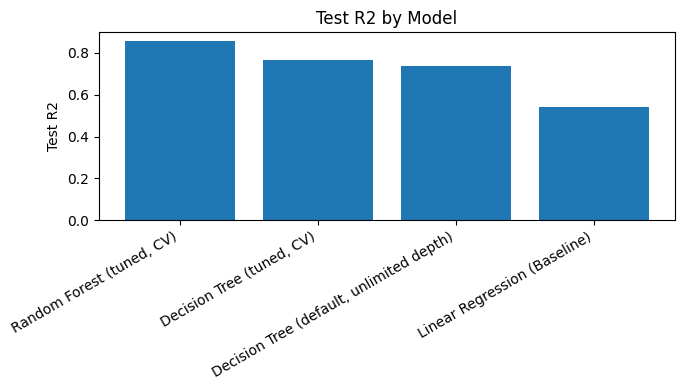

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(model_results["Model"], model_results["Test_R2"])
plt.ylabel("Test R2")
plt.title("Test R2 by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Model Behavior — Strengths / Weaknesses

**Linear Regression (Baseline)**
- Strengths: fast to train, coefficients are directly interpretable, good reference point for judging whether newer models actually improve.
- Weaknesses: assumes a linear relationship, can't capture non-linear patterns or interactions; sensitive to multicollinearity and outliers.

**Decision Tree (unlimited depth)**
- Strengths: captures non-linear relationships and interactions automatically; not sensitive to feature scale.
- Weaknesses: almost always overfits when unconstrained — the `dt_depth_df` table shows the train/test gap directly; a single tree has high variance, small data changes can shift the tree structure a lot.

**Decision Tree (tuned via GridSearchCV)**
- Strengths: `max_depth` + `min_samples_leaf` + `min_samples_split` chosen by 5-fold CV on train only, so the train/test gap shrinks substantially compared to the unlimited-depth tree, while still keeping non-linear modeling power.
- Weaknesses: variance problem isn't fully solved, just constrained; a single tree is still less stable than an ensemble.

**Random Forest (tuned via RandomizedSearchCV)**
- Strengths: bagging + random feature subsets already reduces variance vs a single tree; adding `max_depth`/`min_samples_leaf`/`max_features` tuning on top closes most of the remaining train/test gap while keeping the highest test R2 of the three models.
- Weaknesses: slower to train (grid/random search over many trees); harder to interpret a single prediction (would need SHAP or similar); still can't extrapolate well beyond the range of training data.

## 8. Summary / Next Steps

- Full ranking by test R2 is in `model_results`.
- If Random Forest test R2 clearly beats baseline, ClosePrice likely has non-linear/interaction structure the linear model can't capture.
- Next: hyperparameter search for Random Forest (`n_estimators`, `max_depth`, `min_samples_leaf`) with cross-validation; consider Gradient Boosting / XGBoost for Week 6.


## 9. Push to GitHub

In [12]:
# 1. 挂载Google Drive（如果还没挂载）
from google.colab import drive
drive.mount('/content/drive')

# 2. 输入token（不会保存到文件）
import getpass
token = getpass.getpass("输入你的GitHub Token: ")

!git remote set-url origin https://{token}@github.com/rongweishen63-blip/idx-exchange-project.git


# 3. Clone repo
%cd /content
!git clone https://{token}@github.com/rongweishen63-blip/idx-exchange-project.git
%cd idx-exchange-project

# 4. 复制notebook
!cp "/content/drive/MyDrive/Colab Notebooks/idx_project.ipynb" .

# 5. Push
!git config --global user.email "rongweishen63@gmail.com"
!git config --global user.name "rongweishen63-blip"

!cp "/content/drive/MyDrive/Colab Notebooks/04_model_comparison.ipynb" .

!git add 04_model_comparison.ipynb
!git commit -m "model compare"
!git push origin main

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
输入你的GitHub Token: ··········
/content
fatal: destination path 'idx-exchange-project' already exists and is not an empty directory.
/content/idx-exchange-project
cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/04_model_comparison.ipynb': No such file or directory
fatal: pathspec '04_model_comparison.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
